## Inicialización

Eres analista en una gran tienda online. Junto con el departamento de marketing has recopilado una lista de hipótesis que pueden ayudar a aumentar los ingresos.

Tienes que priorizar estas hipótesis, lanzar un test A/B y analizar los resultados.

# **Descripción de los datos**

**Datos utilizados en la primera parte del proyecto**

`/datasets/hypotheses_us.csv`

- `Hypotheses`: breves descripciones de las hipótesis.
- `Reach`: alcance del usuario, en una escala del uno a diez.
- `Impact`: impacto en los usuarios, en una escala del uno al diez.
- `Confidence`: confianza en la hipótesis, en una escala del uno al diez.
- `Effort`: los recursos necesarios para probar una hipótesis, en una escala del uno al diez. Cuanto mayor sea el valor `Effort`, más recursos requiere la prueba.

Asegúrate de preprocesar los datos. Es posible que haya errores en los datasets originales; por ejemplo, algunos de los visitantes podrían haber entrado tanto en el grupo A como en el grupo B.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

# Cargar los datasets
orders = pd.read_csv('orders_us.csv')
visits = pd.read_csv('visits_us.csv')

# 1. Convertir fechas al formato correcto
orders['date'] = pd.to_datetime(orders['date'], errors='coerce')
visits['date'] = pd.to_datetime(visits['date'], errors='coerce')

# 2. Buscar usuarios que aparecen en ambos grupos A y B
duplicados = (
    orders.groupby('visitorId')['group']
    .nunique()
    .reset_index()
)
usuarios_ambos = duplicados[duplicados['group'] > 1]['visitorId']

print(f'Usuarios en ambos grupos: {len(usuarios_ambos)}')

# 3. Eliminar esos usuarios del conjunto de datos
orders_clean = orders[~orders['visitorId'].isin(usuarios_ambos)]

# 4. Verificar datos faltantes o anómalos
print(orders_clean.isna().sum())
print(visits.isna().sum())

# 5. Revisar valores negativos o fuera de rango
print(orders_clean.describe())


Usuarios en ambos grupos: 58
transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64
date      0
group     0
visits    0
dtype: int64
       transactionId     visitorId                           date  \
count   1.016000e+03  1.016000e+03                           1016   
mean    2.155085e+09  2.128677e+09  2019-08-15 07:47:42.992125952   
min     1.062393e+06  5.114589e+06            2019-08-01 00:00:00   
25%     1.143481e+09  1.043655e+09            2019-08-07 00:00:00   
50%     2.144499e+09  2.150274e+09            2019-08-15 00:00:00   
75%     3.256513e+09  3.146991e+09            2019-08-23 00:00:00   
max     4.288552e+09  4.283872e+09            2019-08-31 00:00:00   
std     1.234372e+09  1.221578e+09                            NaN   

            revenue  
count   1016.000000  
mean     130.770866  
min        5.000000  
25%       20.775000  
50%       50.100000  
75%      126.950000  
max    19920.400000  
std      648.079

### **Parte 1. Priorizar hipótesis**

El archivo hypotheses_us.csv contiene nueve hipótesis sobre cómo aumentar los ingresos de una tienda online con Reach, Impact, Confidence y Effort especificados para cada una.

1. Aplicar el framework ICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.

In [22]:
# Cargar archivo
hypotheses = pd.read_csv('hypotheses_us.csv', sep=';')

# Ver primeras filas
print(hypotheses.head())
print(hypotheses.columns)

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  
Index(['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort'], dtype='object')


 Calcular el score ICE

In [23]:
# Crear una nueva columna 'ICE'
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordenar hipótesis por ICE descendente
ice_sorted = hypotheses.sort_values(by='ICE', ascending=False)

# Mostrar solo las columnas relevantes
print(ice_sorted[['Hypothesis', 'ICE']])

                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


2. Aplicar el framework RICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.

In [24]:
# Calcular RICE
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordenar de mayor a menor prioridad
rice_sorted = hypotheses.sort_values(by='RICE', ascending=False)

# Mostrar resultados
print(rice_sorted[['Hypothesis', 'RICE']])

                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


3. Mostrar cómo cambia la priorización de hipótesis cuando utilizas RICE en lugar de ICE. Proporcionar una explicación de los cambios.

In [25]:
# Mostrar ambas priorizaciones
comparison = hypotheses[['Hypothesis', 'ICE', 'RICE']].sort_values(by='RICE', ascending=False)
comparison

,Hypothesis,ICE,RICE
7,Add a subscription form to all the main pages....,11.200000,112.0
2,Add product recommendation blocks to the store...,7.000000,56.0
0,Add two new channels for attracting traffic. T...,13.333333,40.0
6,Show banners with current offers and sales on ...,8.000000,40.0
8,Launch a promotion that gives users discounts ...,16.200000,16.2
3,Change the category structure. This will incre...,1.125000,9.0
1,Launch your own delivery service. This will sh...,2.000000,4.0
5,Add a customer review page. This will increase...,1.333333,4.0
4,Change the background color on the main page. ...,1.000000,3.0


Al comparar las métricas ICE y RICE, observamos que la priorización de hipótesis cambia significativamente al incluir el factor Reach.

Con ICE, las hipótesis más valiosas parecían ser las que tenían mayor impacto y menor esfuerzo, como “Launch a promotion that gives users discounts”.
Sin embargo, al aplicar RICE, hipótesis como “Add a subscription form to all the main pages” y “Add product recommendation blocks” pasaron al primer lugar, ya que alcanzan a un mayor número de usuarios.

Esto demuestra que al considerar el alcance, las ideas que pueden beneficiar a un público más amplio adquieren mayor relevancia estratégica, incluso si su impacto individual no es el más alto.

Por lo tanto, RICE ofrece una visión más completa y realista para priorizar iniciativas que maximicen el efecto global sobre los ingresos de la tienda.

## **Parte 2. Análisis del test A/B**

Realizaste una prueba A/B y obtuviste los resultados descritos en los archivos `orders_us.csv` y `visits_us.csv`.

**Ejercicio**

Analiza el test A/B:

### 1. Representa gráficamente el ingreso acumulado por grupo. Haz conclusiones y conjeturas.

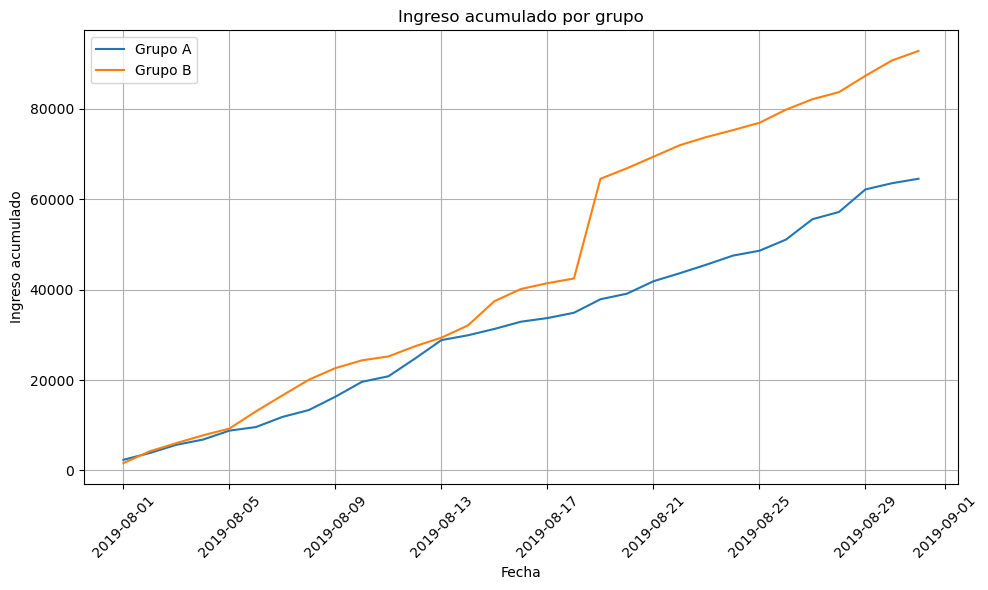

In [26]:
# Calcular ingresos acumulados diarios por grupo
daily_revenue = orders.groupby(['date', 'group'])['revenue'].sum().reset_index()

# Calcular ingreso acumulado
daily_revenue['cumulative_revenue'] = daily_revenue.groupby('group')['revenue'].cumsum()

# Graficar
plt.figure(figsize=(10,6))
for group in daily_revenue['group'].unique():
    group_data = daily_revenue[daily_revenue['group'] == group]
    plt.plot(group_data['date'], group_data['cumulative_revenue'], label=f'Grupo {group}')

plt.title('Ingreso acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. El grupo B supera consistentemente al grupo A en ingresos acumulados.
Desde los primeros días, las líneas crecen de forma paralela, pero a partir de la mitad del periodo (alrededor del 13–17 de agosto), el grupo B comienza a separarse con una pendiente más pronunciada.

2. Se observa un incremento muy pronunciado a mitad del periodo (entre el 17 y el 20 de agosto).
Esto podría deberse a uno o varios pedidos de alto valor. Será importante identificarlos antes de sacar conclusiones estadísticas, ya que pueden distorsionar los resultados.



### 2. Representa gráficamente el tamaño de pedido promedio acumulado por grupo. Haz conclusiones y conjeturas.

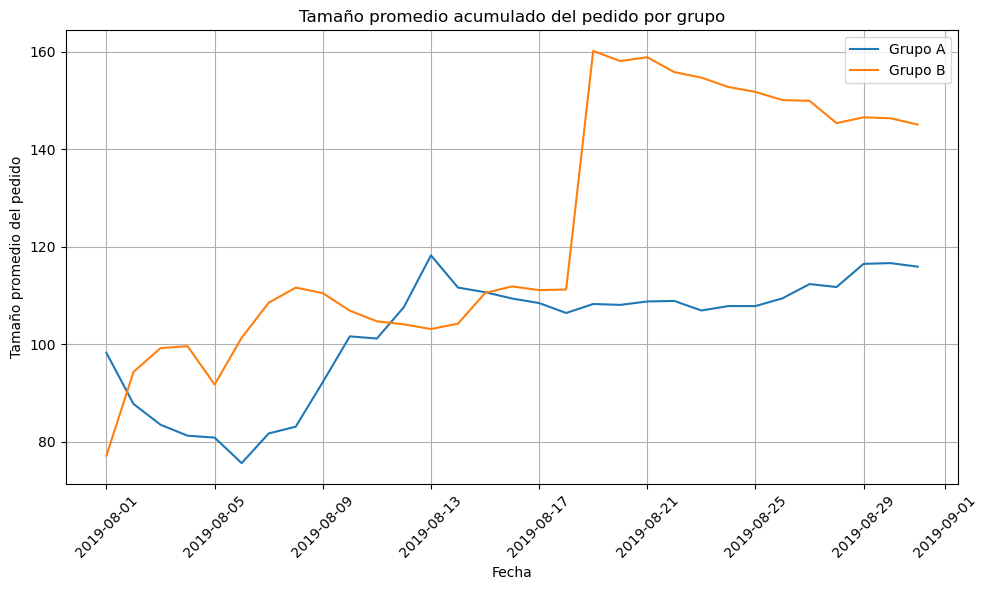

In [27]:
# Agrupar ingresos y pedidos diarios por grupo
daily_orders = orders.groupby(['date', 'group']).agg(
    orders_count=('transactionId', 'nunique'),
    revenue_sum=('revenue', 'sum')
).reset_index()

# Calcular valores acumulados
daily_orders['cum_orders'] = daily_orders.groupby('group')['orders_count'].cumsum()
daily_orders['cum_revenue'] = daily_orders.groupby('group')['revenue_sum'].cumsum()

# Calcular tamaño promedio acumulado
daily_orders['avg_order_value'] = daily_orders['cum_revenue'] / daily_orders['cum_orders']

# Graficar
plt.figure(figsize=(10,6))
for group in daily_orders['group'].unique():
    group_data = daily_orders[daily_orders['group'] == group]
    plt.plot(group_data['date'], group_data['avg_order_value'], label=f'Grupo {group}')

plt.title('Tamaño promedio acumulado del pedido por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tamaño promedio del pedido')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. El grupo B mantiene un tamaño de pedido promedio mayor durante casi todo el experimento.
Desde los primeros días, el grupo B (línea naranja) supera consistentemente al grupo A (línea azul), especialmente después del 17 de agosto, donde se observa un salto abrupto en el promedio del grupo B.
Esto indica que los pedidos en el grupo B fueron, en promedio, más costosos.

2. El incremento tan pronunciado alrededor del 17 de agosto es una señal clara de uno o varios pedidos de alto valor que elevaron artificialmente el promedio.
Este tipo de comportamiento suele afectar la interpretación, por lo que será importante identificar y filtrar los outliers en los próximos pasos.

3. El grupo A muestra un comportamiento más estable.
Aunque inicia con un tamaño de pedido ligeramente inferior, su tendencia es más suave y constante, sin picos marcados. Esto sugiere un patrón de compras más regular entre sus usuarios.

4. Basado en el tamaño promedio acumulado, el grupo B parece más rentable, pero el resultado no es totalmente confiable debido a posibles outliers.

### 3.Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A. Haz conclusiones y conjeturas.

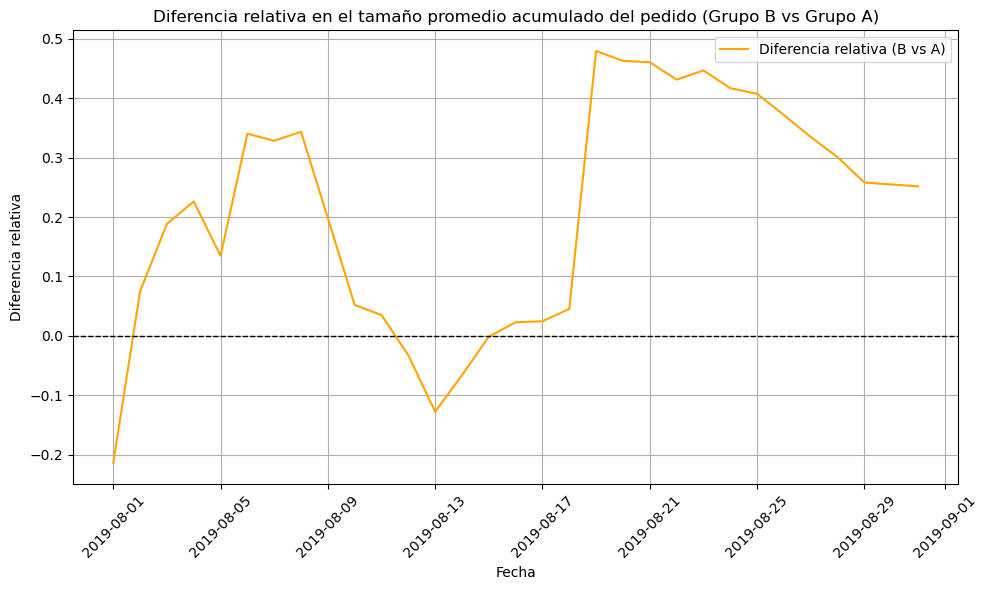

In [28]:
# Dividir por grupo
groupA = daily_orders[daily_orders['group'] == 'A'][['date', 'avg_order_value']].rename(columns={'avg_order_value': 'A_avg'})
groupB = daily_orders[daily_orders['group'] == 'B'][['date', 'avg_order_value']].rename(columns={'avg_order_value': 'B_avg'})

# Unir por fecha
merged = pd.merge(groupA, groupB, on='date')

# Calcular la diferencia relativa
merged['rel_diff'] = merged['B_avg'] / merged['A_avg'] - 1

# Graficar
plt.figure(figsize=(10,6))
plt.plot(merged['date'], merged['rel_diff'], color='orange', label='Diferencia relativa (B vs A)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Diferencia relativa en el tamaño promedio acumulado del pedido (Grupo B vs Grupo A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. El grupo B tuvo pedidos promedio más grandes la mayor parte del tiempo.
Durante la mayor parte del periodo, la línea se mantiene por encima de 0, lo que indica que el tamaño promedio de los pedidos en el grupo B fue superior al del grupo A.

2. El pico alrededor del 17–20 de agosto destaca como un valor atípico.
El despegue en esa fecha coincide con los picos observados en los gráficos anteriores de ingresos y tamaño promedio.

3. Hay un breve periodo al inicio donde el grupo A supera al B.
En los primeros días de agosto, la diferencia cae por debajo de 0, lo que significa que el grupo A tuvo pedidos ligeramente mayores en esa etapa inicial.
Sin embargo, esta tendencia se revierte rápidamente.

### 4. Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.

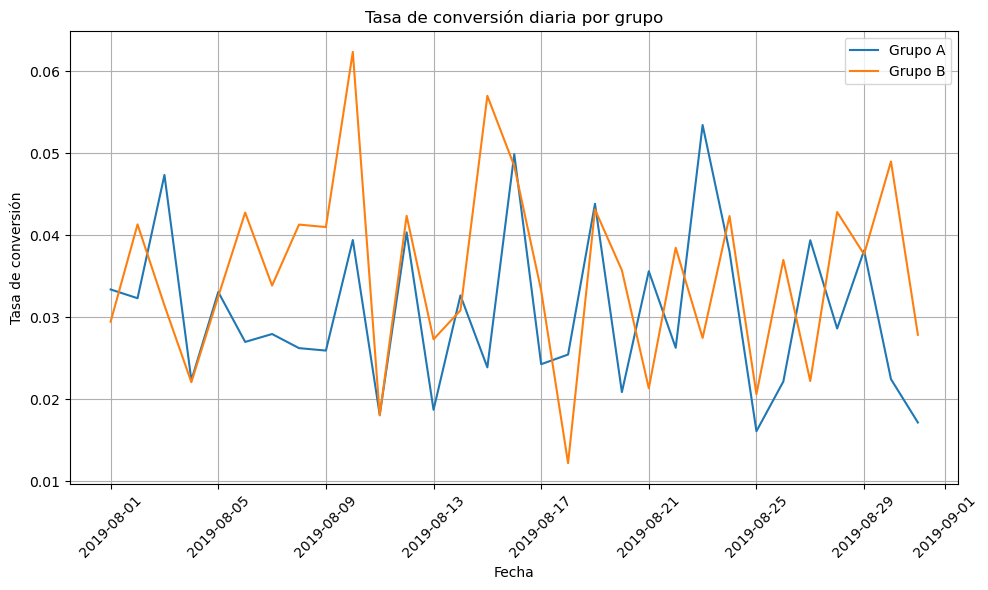

In [29]:
# Cambiar el nombre de la columna antes del merge
daily_orders = daily_orders.rename(columns={'orders_count': 'orders'})

# Unir con el dataset de visitas
daily_data = pd.merge(visits, daily_orders, on=['date', 'group'], how='left')

# Rellenar los días sin pedidos con 0
daily_data['orders'] = daily_data['orders'].fillna(0)

# Calcular la tasa de conversión diaria
daily_data['conversion'] = daily_data['orders'] / daily_data['visits']

# Graficar tasas de conversión diarias
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for group in daily_data['group'].unique():
    group_data = daily_data[daily_data['group'] == group]
    plt.plot(group_data['date'], group_data['conversion'], label=f'Grupo {group}')

plt.title('Tasa de conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Ambos grupos presentan un comportamiento muy similar.
Las curvas de los grupos A y B fluctúan de manera paralela a lo largo del tiempo, con variaciones diarias relativamente pequeñas.
Esto sugiere que no hay diferencias consistentes en el porcentaje de visitantes que realizaron compras entre los dos grupos.
2. El grupo B muestra una ligera ventaja en algunos momentos.
En varios tramos del experimento, la línea del grupo B (naranja) se mantiene por encima de la del grupo A (azul), lo que indica que el grupo B tuvo una tasa de conversión algo mayor en ciertos días.
Sin embargo, esta diferencia no es sostenida y se alterna con periodos en los que el grupo A iguala o supera ligeramente al grupo B.
3.  El análisis de la tasa de conversión diaria sugiere que no existe una diferencia clara y sostenida entre los grupos A y B.
Aunque el grupo B muestra algunos picos de rendimiento, estos no se mantienen de forma consistente.

Por lo tanto, es probable que la mejora aparente en el grupo B se deba a fluctuaciones aleatorias o a la influencia de valores atípicos en determinados días.



### 5.Traza un gráfico de dispersión del número de pedidos por usuario. Haz conclusiones y conjeturas.

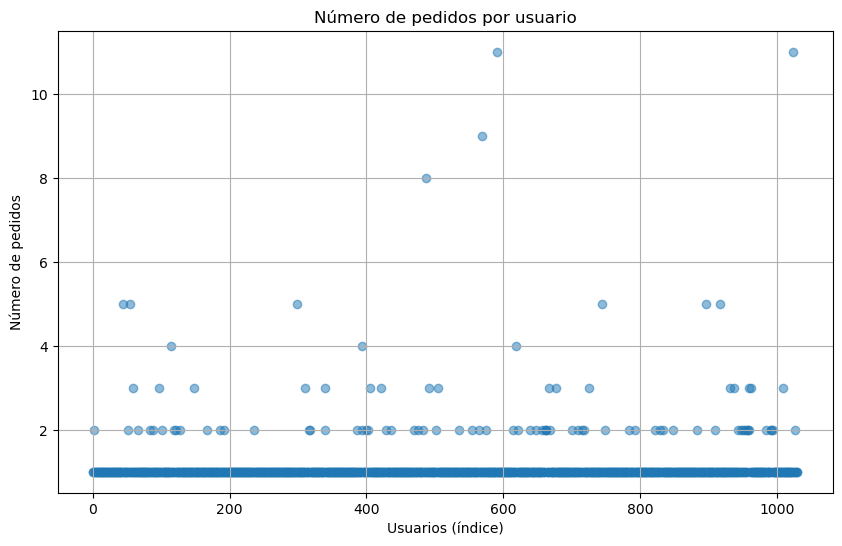

In [30]:
# Contar pedidos por usuario
orders_per_user = orders.groupby('visitorId').agg({'transactionId': 'nunique'}).reset_index()
orders_per_user.columns = ['visitorId', 'orders']

# Graficar dispersión
plt.figure(figsize=(10,6))
plt.scatter(range(len(orders_per_user)), orders_per_user['orders'], alpha=0.5)
plt.title('Número de pedidos por usuario')
plt.xlabel('Usuarios (índice)')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.show()


1. La mayoría de los usuarios realizó un solo pedido.
El gráfico muestra una gran concentración de puntos en torno al valor 1 en el eje Y, lo que indica que la mayoría de los visitantes compró solo una vez durante el experimento.
Esto es un comportamiento típico en tiendas online, donde la mayoría de los usuarios realiza una única transacción.
2. Existen algunos usuarios con múltiples pedidos.
Aunque la mayoría se concentra entre 1 y 2 pedidos, hay algunos puntos dispersos más arriba (entre 4 y hasta más de 10 pedidos).
Estos casos representan a usuarios recurrentes o muy activos, que realizaron varias compras a lo largo del periodo.
3. Presencia clara de valores atípicos (outliers).
Los puntos por encima de 5 pedidos son poco frecuentes, y los que superan los 10 pedidos son claramente anómalos respecto al resto de los usuarios.
Estos valores pueden distorsionar métricas como el tamaño promedio de pedido o los ingresos totales por usuario.

### 6.Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía.

In [31]:
# Calcular pedidos por usuario
ordersByUsers = orders.groupby('visitorId').agg({'transactionId': 'nunique'}).reset_index()
ordersByUsers.columns = ['visitorId', 'orders']

# Calcular percentiles con NumPy
percentiles = np.percentile(ordersByUsers['orders'], [90, 95, 99])
print('Percentiles 90, 95 y 99:', percentiles)

Percentiles 90, 95 y 99: [1. 2. 4.]


Esto significa que solo el 1 % de los usuarios realizó más de 4 pedidos, por lo que esos casos son anómalos o atípicos (outliers).

Los percentiles 90, 95 y 99 del número de pedidos por usuario son 1, 2 y 4 respectivamente.
Esto indica que la mayoría de los usuarios realizó uno o dos pedidos durante el experimento, y solo un número muy pequeño (menos del 1 %) realizó más de 4 pedidos.

### 7. Traza un gráfico de dispersión de los precios de los pedidos. Haz conclusiones y conjeturas.

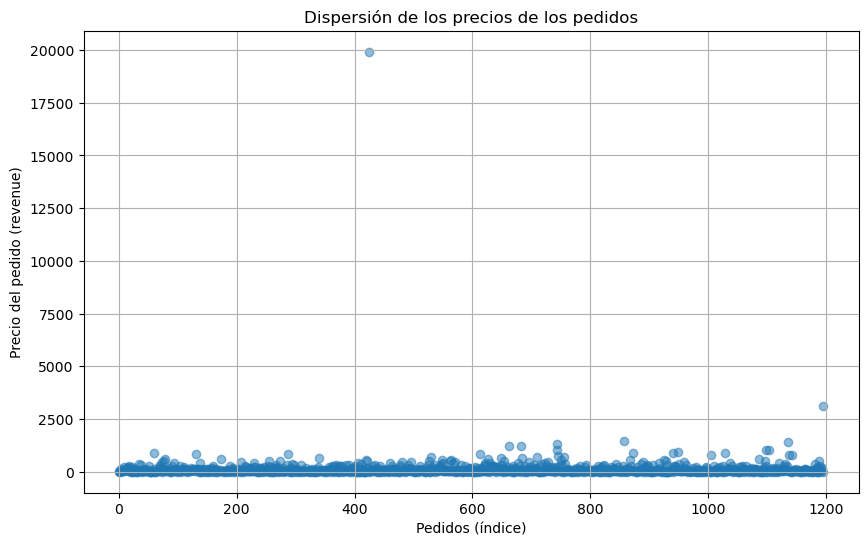

In [32]:
# Graficar el precio (revenue) de cada pedido
plt.figure(figsize=(10,6))
plt.scatter(range(len(orders)), orders['revenue'], alpha=0.5)
plt.title('Dispersión de los precios de los pedidos')
plt.xlabel('Pedidos (índice)')
plt.ylabel('Precio del pedido (revenue)')
plt.grid(True)
plt.show()

La mayoría de los pedidos tienen valores bajos.
1. La gran concentración de puntos en la parte inferior del gráfico (entre 0 y 1000 aproximadamente) indica que la mayoría de los pedidos tienen precios relativamente pequeños.
Este patrón es común en tiendas online, donde la mayoría de las compras son de artículos económicos.
2. Existen pedidos con valores atípicamente altos (outliers).
Se pueden observar varios puntos aislados, especialmente uno que supera los 20 000, y algunos más alrededor de 3000–4000.
Estos valores son anomalías en comparación con el resto del conjunto de datos y podrían corresponder a:

	•	Compras masivas o de alto valor,

	•	Errores en el registro del precio,
	
	•	O casos excepcionales de clientes con gasto inusualmente alto.


### 8. Calcula los percentiles 95 y 99 de los precios de los pedidos. Define el punto en el cual un punto de datos se convierte en una anomalía.

In [33]:
# Calcular percentiles 95 y 99 de los precios de los pedidos con NumPy
percentiles = np.percentile(orders['revenue'], [95, 99])
print('Percentiles 95 y 99:', percentiles)

# Definir el punto donde un pedido se considera anómalo
threshold = percentiles[1]
print(f'\nUn pedido se considera una anomalía si su precio es mayor a {threshold:.2f}')

Percentiles 95 y 99: [435.54  900.904]

Un pedido se considera una anomalía si su precio es mayor a 900.90


La mayoría de los pedidos se concentra por debajo de los $450, lo que indica una estructura de precios bastante uniforme y centrada en compras de bajo valor.
Sin embargo, un pequeño grupo de pedidos (alrededor del 1 %) supera los $900.90, lo que los convierte en pedidos anómalos que podrían influir de manera desproporcionada en las métricas promedio.

Por tanto, un pedido se considera una anomalía si su valor excede los $900.90.
Estos valores extremos deben filtrarse o analizarse por separado antes de realizar comparaciones entre los grupos A y B, para evitar que distorsionen los resultados de los análisis de ingresos y tamaño promedio de pedido.

### 9. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

In [34]:
# Calcular el número de pedidos únicos por grupo
orders_by_group = orders.groupby('group').agg({'transactionId': 'nunique'}).reset_index()
orders_by_group.columns = ['group', 'orders']

# Calcular el número total de visitas por grupo
visits_by_group = visits.groupby('group').agg({'visits': 'sum'}).reset_index()

# Unir ambas tablas
conversion = orders_by_group.merge(visits_by_group, on='group')
conversion['conversion'] = conversion['orders'] / conversion['visits']
print(conversion)

  group  orders  visits  conversion
0     A     557   18736    0.029729
1     B     640   18916    0.033834


In [35]:
# Datos del experimento
ordersA, visitsA = 557, 18736
ordersB, visitsB = 640, 18916

# Tasas de conversión
pA = ordersA / visitsA
pB = ordersB / visitsB

# Proporción combinada
p_combined = (ordersA + ordersB) / (visitsA + visitsB)

# Estadístico Z
z_value = (pA - pB) / np.sqrt(p_combined * (1 - p_combined) * (1/visitsA + 1/visitsB))

# p-valor (bilateral)
p_value = (1 - st.norm.cdf(abs(z_value))) * 2

print(f'Z-value: {z_value:.4f}')
print(f'p-value: {p_value:.4f}')

Z-value: -2.2700
p-value: 0.0232


El p-value (0.0232) es menor que 0.05, por lo tanto:
Rechazamos la hipótesis nula (H₀) de que las conversiones de A y B son iguales.

El grupo B (3.38 %) presenta una tasa de conversión significativamente superior al grupo A (2.97 %).
La prueba z arroja un valor p = 0.0232, menor al nivel de significancia de 0.05, lo que confirma que esta diferencia no se debe al azar.

En consecuencia, podemos afirmar con un 95 % de confianza que el cambio aplicado al grupo B tuvo un impacto positivo real en la conversión.


### 10. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

In [36]:
# Separar los valores de revenue por grupo
groupA = orders[orders['group'] == 'A']['revenue']
groupB = orders[orders['group'] == 'B']['revenue']

# Calcular la media de cada grupo
print(f"Tamaño promedio del pedido (A): {groupA.mean():.2f}")
print(f"Tamaño promedio del pedido (B): {groupB.mean():.2f}")

# Prueba de Mann–Whitney U (bilateral)
alpha = 0.05
results = st.mannwhitneyu(groupA, groupB, alternative='two-sided')

print(f"U-Statistic: {results.statistic:.2f}")
print(f"p-value: {results.pvalue:.4f}")

# Evaluar significancia
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: existe una diferencia significativa entre los grupos.")
else:
    print("No se puede rechazar la hipótesis nula: no hay diferencia significativa entre los grupos.")

Tamaño promedio del pedido (A): 115.90
Tamaño promedio del pedido (B): 145.06
U-Statistic: 175872.50
p-value: 0.6915
No se puede rechazar la hipótesis nula: no hay diferencia significativa entre los grupos.


El valor de p = 0.6915 indica que la diferencia observada entre los grupos no es estadísticamente significativa.
Esto significa que no hay evidencia suficiente para afirmar que los tamaños promedio de pedido difieren entre los grupos A y B.

A partir de los datos en bruto, no se puede rechazar la hipótesis nula.
No existe una diferencia estadísticamente significativa entre el tamaño promedio de los pedidos en los grupos A y B.

Aunque el grupo B tiene un valor medio ligeramente mayor, esta diferencia no es suficiente para considerarse un efecto real del cambio implementado.

### 11. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

In [37]:
# Filtro 1: eliminar pedidos con revenue > 900.90 
orders_filtered = orders[orders['revenue'] <= 900.90]

# Filtro 2: eliminar usuarios con más de 4 pedidos 
orders_per_user = orders_filtered.groupby('visitorId')['transactionId'].nunique().reset_index()
orders_per_user.columns = ['visitorId', 'orders']
users_to_keep = orders_per_user[orders_per_user['orders'] <= 4]['visitorId']

orders_filtered = orders_filtered[orders_filtered['visitorId'].isin(users_to_keep)]

# Contar pedidos por grupo
orders_by_group = orders_filtered.groupby('group').agg({'transactionId': 'nunique'}).reset_index()
orders_by_group.columns = ['group', 'orders']

# Calcular visitas por grupo
visits_by_group = visits.groupby('group').agg({'visits': 'sum'}).reset_index()

# Unir y calcular conversión
conversion = pd.merge(orders_by_group, visits_by_group, on='group')
conversion['conversion'] = conversion['orders'] / conversion['visits']

print(conversion)

  group  orders  visits  conversion
0     A     515   18736    0.027487
1     B     601   18916    0.031772


In [38]:
# Datos filtrados
ordersA, visitsA = 515, 18736
ordersB, visitsB = 601, 18916

# Tasa de conversión por grupo
pA = ordersA / visitsA
pB = ordersB / visitsB

# Proporción combinada
p_combined = (ordersA + ordersB) / (visitsA + visitsB)

# Estadístico z y valor p (bilateral)
z_value = (pA - pB) / np.sqrt(p_combined * (1 - p_combined) * (1/visitsA + 1/visitsB))
p_value = (1 - st.norm.cdf(abs(z_value))) * 2

print(f'Z-value: {z_value:.4f}')
print(f'p-value: {p_value:.4f}')

Z-value: -2.4513
p-value: 0.0142


Después de eliminar los outliers (usuarios con más de 4 pedidos y pedidos con revenue > 900.90), la conversión del grupo B (3.18 %) sigue siendo significativamente superior a la del grupo A (2.75 %).

La prueba z arroja un p-valor de 0.0142, menor al umbral de 0.05, lo que indica que la mejora en conversión no se debe al azar.

Esto demuestra que el cambio aplicado al grupo B tuvo un impacto real y positivo en la conversión de usuarios.

### 12. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

In [39]:
# Conservar solo usuarios con <= 4 pedidos
valid_users = orders_per_user[orders_per_user['orders'] <= 4]['visitorId']
orders_filtered = orders_filtered[orders_filtered['visitorId'].isin(valid_users)]

# Separar valores de revenue por grupo
groupA = orders_filtered[orders_filtered['group'] == 'A']['revenue']
groupB = orders_filtered[orders_filtered['group'] == 'B']['revenue']

# Medias
print(f"Tamaño promedio de pedido (A): {groupA.mean():.2f}")
print(f"Tamaño promedio de pedido (B): {groupB.mean():.2f}")

# Prueba Mann–Whitney U bilateral
alpha = 0.05
results = st.mannwhitneyu(groupA, groupB, alternative='two-sided')

print(f"U-Statistic: {results.statistic:.2f}")
print(f"p-value: {results.pvalue:.4f}")

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: existe una diferencia significativa.")
else:
    print("No se puede rechazar la hipótesis nula: no hay diferencia significativa.")

Tamaño promedio de pedido (A): 102.95
Tamaño promedio de pedido (B): 101.37
U-Statistic: 154307.00
p-value: 0.9332
No se puede rechazar la hipótesis nula: no hay diferencia significativa.


Después de eliminar los outliers, los tamaños promedio de pedido entre los grupos A (102.95) y B (101.37) son prácticamente iguales.

La prueba de Mann–Whitney arroja un p-valor = 0.9332, lo que indica que no hay diferencia estadísticamente significativa entre los grupos.

Por tanto, no se puede afirmar que el cambio implementado en el grupo B haya afectado el tamaño promedio de los pedidos.

### 13. Toma una decisión basada en los resultados de la prueba. Las decisiones posibles son: 1. Parar la prueba, considerar a uno de los grupos como líder. 2. Parar la prueba, concluir que no hay diferencia entre los grupos. 3. Continuar la prueba.

La tasa de conversión fue significativamente mayor en el grupo B, tanto con los datos originales como con los filtrados.

El tamaño promedio de pedido no mostró diferencias significativas entre grupos.
Esto implica que los usuarios del grupo B compraron más a menudo, pero no gastaron más dinero por compra.

Como resultado, el grupo B genera más ingresos totales gracias al mayor número de pedidos, sin afectar el ticket medio.

1. Parar la prueba y considerar al grupo B como líder.

El grupo B muestra una mejora estadísticamente significativa en la conversión, lo que significa que el cambio aplicado aumentó la cantidad de pedidos realizados.
No hubo impacto negativo en el tamaño promedio de pedido, por lo que el incremento en conversiones implica un aumento real en ingresos totales.

Continuar la prueba probablemente no cambiaría las conclusiones, ya que los resultados son consistentes y estadísticamente robustos incluso después del filtrado de outliers.